# 4.10 策略业绩归因分析（Performance Attribution）

## 学习目标
- 理解 Brinson-Hood-Beebower（BHB）归因框架
- 将策略超额收益分解为行业配置效应、个股选择效应和交互效应
- 相对基准（如沪深300）进行完整的业绩归因报告


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)
print('Libraries loaded')


Libraries loaded


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 为什么需要业绩归因？

一个基金今年跑赢基准 5%，原因可能是：
1. **选对了行业**（配置了更多科技股，科技股整体暴涨）
2. **选对了个股**（在科技行业里选了龙头，跑赢了科技行业平均）
3. 以上两者的叠加（**交互效应**）

**Brinson-Hood-Beebower 模型（1986）** 将超额收益精确分解为这三个来源。


In [3]:
# 模拟 5 个行业的基准权重、组合权重、基准收益率、组合收益率
np.random.seed(42)
sectors = ['科技','金融','消费','医药','工业']

# 基准权重（如沪深300的行业分布）
w_b = np.array([0.25, 0.30, 0.20, 0.15, 0.10])
# 组合权重（基金经理的超配/低配）
w_p = np.array([0.35, 0.20, 0.25, 0.15, 0.05])
# 基准各行业收益率
r_b = np.array([0.15, 0.05, 0.08, 0.12, 0.03])
# 组合各行业收益率（选股效果）
r_p = np.array([0.18, 0.06, 0.07, 0.14, 0.04])

df = pd.DataFrame({'行业': sectors, 'w_b':w_b, 'w_p':w_p, 'r_b':r_b, 'r_p':r_p})
df.set_index('行业', inplace=True)
print(df.round(3).to_string())


     w_b   w_p   r_b   r_p
行业                        
科技  0.25  0.35  0.15  0.18
金融  0.30  0.20  0.05  0.06
消费  0.20  0.25  0.08  0.07
医药  0.15  0.15  0.12  0.14
工业  0.10  0.05  0.03  0.04


## 2. BHB 归因公式

$$\text{行业配置效应} = (w^p_i - w^b_i) \times (r^b_i - R^b)$$
$$\text{个股选择效应} = w^b_i \times (r^p_i - r^b_i)$$
$$\text{交互效应} = (w^p_i - w^b_i) \times (r^p_i - r^b_i)$$

其中 $R^b = \sum_i w^b_i r^b_i$ 是基准总收益率。


In [4]:
R_b = (df['w_b'] * df['r_b']).sum()  # 基准总收益
R_p = (df['w_p'] * df['r_p']).sum()  # 组合总收益

df['行业配置效应'] = (df['w_p'] - df['w_b']) * (df['r_b'] - R_b)
df['个股选择效应'] = df['w_b'] * (df['r_p'] - df['r_b'])
df['交互效应']     = (df['w_p'] - df['w_b']) * (df['r_p'] - df['r_b'])
df['总效应']       = df['行业配置效应'] + df['个股选择效应'] + df['交互效应']

total = df[['行业配置效应','个股选择效应','交互效应','总效应']].sum()
print(f'组合总收益:  {R_p:.4f} ({R_p:.2%})')
print(f'基准总收益:  {R_b:.4f} ({R_b:.2%})')
print(f'超额收益:    {R_p-R_b:.4f} ({R_p-R_b:.2%})')
print(f'\n归因分解:')
print(f'  行业配置效应: {total["行业配置效应"]:.4f}')
print(f'  个股选择效应: {total["个股选择效应"]:.4f}')
print(f'  交互效应:     {total["交互效应"]:.4f}')
print(f'  合计:         {total["总效应"]:.4f} (应≈ {R_p-R_b:.4f})')


组合总收益:  0.1155 (11.55%)
基准总收益:  0.0895 (8.95%)
超额收益:    0.0260 (2.60%)

归因分解:
  行业配置效应: 0.0125
  个股选择效应: 0.0125
  交互效应:     0.0010
  合计:         0.0260 (应≈ 0.0260)


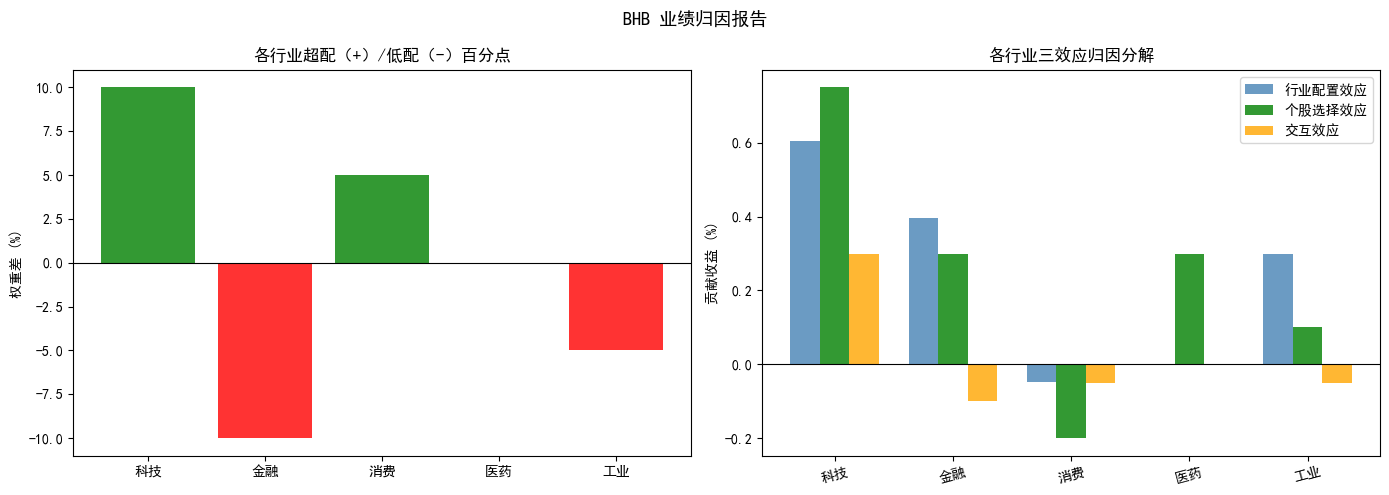

In [5]:
# 可视化行业级别归因
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 各行业配置超配/低配
bar_colors = ['green' if x > 0 else 'red' for x in (df['w_p']-df['w_b'])]
axes[0].bar(df.index, (df['w_p']-df['w_b'])*100, color=bar_colors, alpha=0.8)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('各行业超配（+）/低配（-）百分点')
axes[0].set_ylabel('权重差 (%)')

# 各行业归因贡献
width = 0.25
x = np.arange(len(df))
for i, (col, color) in enumerate(zip(['行业配置效应','个股选择效应','交互效应'], ['steelblue','green','orange'])):
    axes[1].bar(x + i*width, df[col]*100, width, label=col, color=color, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('各行业三效应归因分解')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(df.index, rotation=15)
axes[1].set_ylabel('贡献收益 (%)')
axes[1].legend()
plt.suptitle('BHB 业绩归因报告', fontsize=13)
plt.tight_layout()
plt.show()


## 🎯 练习

1. 设计一个季度再平衡的策略（每季度更换行业权重），用 BHB 框架对 4 个季度分别做归因，哪季度选股最强？
2. 引入「纯选股效应」（Pure Stock Selection）= 个股选择效应 + 交互效应，哪个行业的选股贡献最大？
3. 查阅 Carhart 四因子归因框架，理解如何将 BHB 行业归因扩展到因子层面（市场、规模、价值、动量）。

---
**下一节** → `../05_portfolio/08_dynamic_asset_allocation.ipynb`